In [1]:
using PyPlot, LaTeXStrings, DelimitedFiles


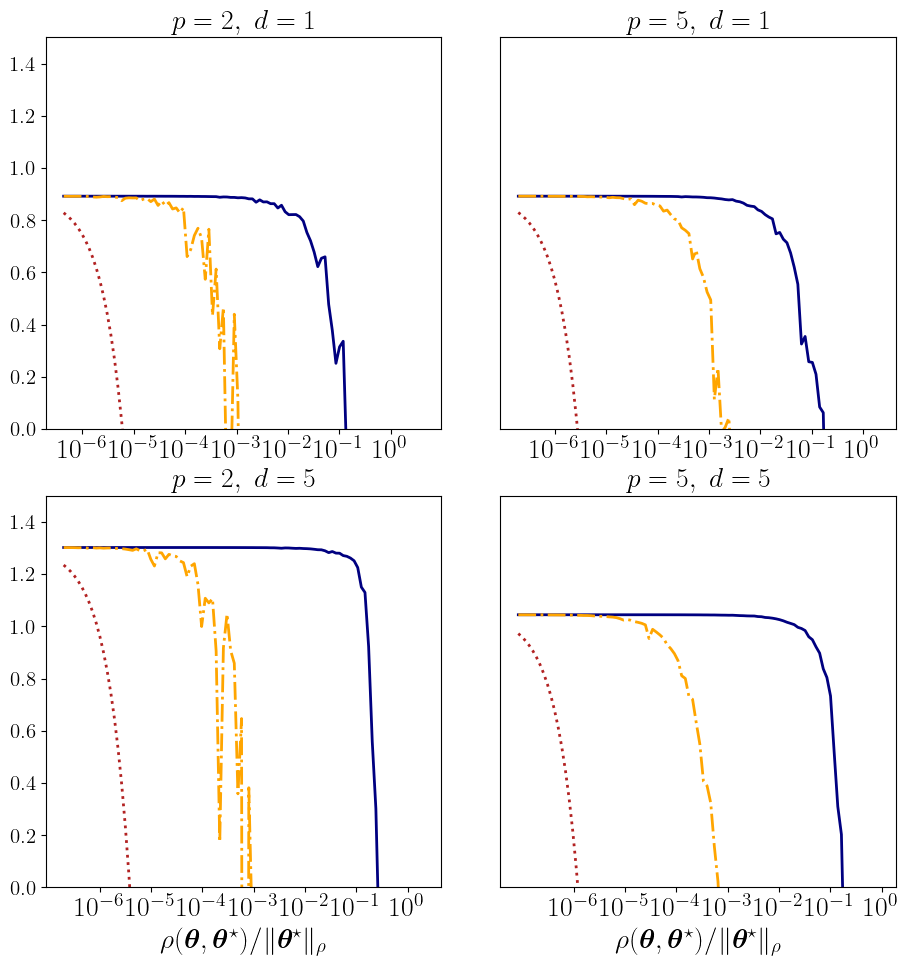

In [2]:

PyPlot.rc("text", usetex=true)
PyPlot.rc("font", family="serif")
PyPlot.rc("text.latex", preamble = raw"\usepackage{amsmath,amssymb,bm}")

data = readdlm("results/noisy_basins_dB=Inf.csv", ',', skipstart=1)

pcol = Int.(data[:,1])
dcol = Int.(data[:,2])
xcol = Float64.(data[:,4])

# columns per your CSV writer:
# 11 mineig_mean, 13 lower_r_mean, 15 lower_proj_mean
mineig = Float64.(data[:,7])
lower_r = Float64.(data[:,9])
lower_proj = Float64.(data[:,11])

pd_list = sort(collect(unique(zip(pcol, dcol))))  # should be 4

basins0 = Dict{Tuple{Int,Int}, NamedTuple}()
for (pi, di) in pd_list
    idx = findall((pcol .== pi) .& (dcol .== di))
    ord = sortperm(xcol[idx])
    ii  = idx[ord]
    basins0[(pi,di)] = (
        x = xcol[ii],
        mineig = mineig[ii],
        lower_r = lower_r[ii],
        lower_proj = lower_proj[ii],
    )
end

max_y = maximum(maximum(basins0[(p,d)].mineig) for (p,d) in pd_list)
ymax  = log10(max_y + 1.1)

fig, axs = subplots(2, 2, figsize=(10,10), constrained_layout=false)
axs = vec(axs)

for (idx, (p,d)) in enumerate(pd_list)
    B = basins0[(p,d)]
    ax = axs[idx]

    ax.set_xscale("log")
    ax.set_ylim(0.0, 1.5)
    # ax.set_xlim(1e-3, 1.5e-1)
    ax.set_xticks([1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1e0])


    ax.set_title(L"p=%$p,\ d=%$d", fontsize=20)

    ax.plot(B.x, B.mineig;     color="navy" ,      linestyle="-",  linewidth=2)
    ax.plot(B.x, B.lower_r;    color="orange",  linestyle="-.", linewidth=2)
    ax.plot(B.x, B.lower_proj; color="firebrick", linestyle=":",  linewidth=2)

    if d == 5
        ax.set_xlabel(L"\rho(\bm{\theta},\bm{\theta}^\star)/\|\bm{\theta}^\star\|_\rho", fontsize=20)
    end

    if p == 5
        ax.set_yticks([])
    end

    ax.tick_params(axis="x", labelsize=20)
    ax.tick_params(axis="y", labelsize=15)
end


# fig, axs = subplots(2, 2; figsize=(10, 10), constrained_layout=true)
# ax00 = axs[1,1]   # top-left
# ax01 = axs[1,2]   # top-right
# ax10 = axs[2,1]   # bottom-left
# ax11 = axs[2,2]   # bottom-right

# for (lab, ax) in zip(["(a)", "(c)", "(b)", "(d)"], axs)
#     ax.text(0.02, 0.96, lab; transform=ax.transAxes,
#         va="top", ha="left", fontsize=16,
#         bbox=Dict("facecolor"=>"white","alpha"=>0.7,"edgecolor"=>"none"))
# end

fig.subplots_adjust(left=0.13, right=0.98, bottom=0.10, top=0.95, wspace=0.15, hspace=0.17)
savefig("figures/tsp_full_envelopes.pdf", bbox_inches="tight")
display(fig)

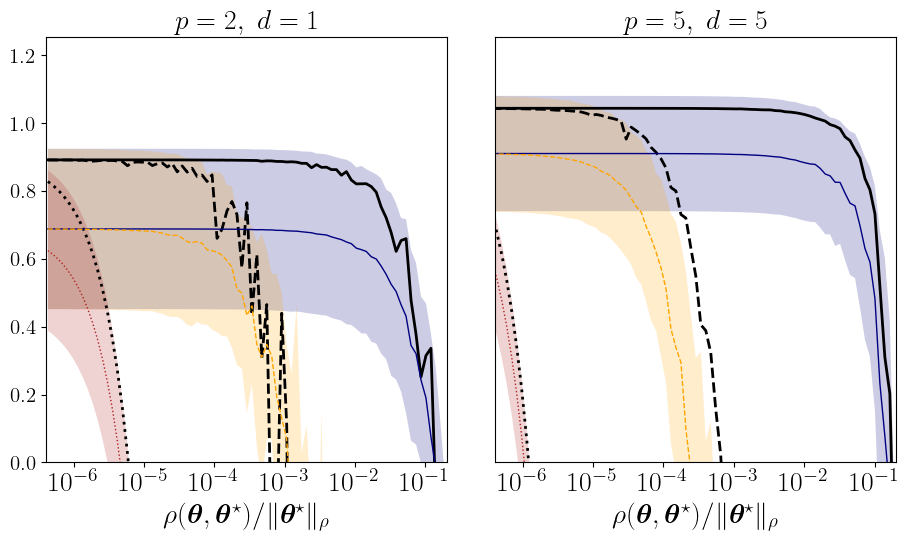

In [3]:


PyPlot.rc("text", usetex=true)
PyPlot.rc("font", family="serif")
PyPlot.rc("text.latex", preamble = raw"\usepackage{amsmath,amssymb,bm}")

signed_log(x) = sign(x) * log10(1 + abs(x))

# helper to plot mean + ribbon in signed_log domain
function plot_mean_ribbon!(ax, x, m, s; color, ls, lw, label="")
    y  = m
    yl = m .- s
    yu = m .+ s
    ax.plot(x, y; color=color, linestyle=ls, linewidth=lw, label=label)
    ax.fill_between(x, yl, yu; color=color, alpha=0.20, linewidth=0)
end

# ----------------- LOAD NOISY (mean ± std) -----------------
dataN = readdlm("results/noisy_basins.csv", ',', skipstart=1)

pN = Int.(dataN[:,1])
dN = Int.(dataN[:,2])
xN = Float64.(dataN[:,4])

mu_mean = Float64.(dataN[:,5])
mu_std  = Float64.(dataN[:,6])

min_mean = Float64.(dataN[:,7])
min_std  = Float64.(dataN[:,8])

low_mean = Float64.(dataN[:,9])
low_std  = Float64.(dataN[:,10])

lowa_mean = Float64.(dataN[:,11])
lowa_std  = Float64.(dataN[:,12])

noisy_full_hessian_basins = Dict{Tuple{Int,Int}, NamedTuple}()

for (pi, di) in unique(zip(pN, dN))
    idx = findall((pN .== pi) .& (dN .== di))
    isempty(idx) && continue
    ord = sortperm(xN[idx])
    ii  = idx[ord]

    noisy_full_hessian_basins[(pi,di)] = (
        x = xN[ii],
        μ_min_noisy_mean = mu_mean[ii][1],
        μ_min_noisy_std  = mu_std[ii][1],
        min_eigval_noisy_mean = min_mean[ii],
        min_eigval_noisy_std  = min_std[ii],
        lower_env_noisy_mean  = low_mean[ii],
        lower_env_noisy_std   = low_std[ii],
        lower_env_analytical_noisy_mean = lowa_mean[ii],
        lower_env_analytical_noisy_std  = lowa_std[ii],
    )
end

# ----------------- LOAD NOISELESS BASELINES -----------------
# change filename if yours is different
data0 = readdlm("results/noisy_basins_dB=Inf.csv", ',', skipstart=1)

p0 = Int.(data0[:,1])
d0 = Int.(data0[:,2])
x0 = Float64.(data0[:,4])

# expected columns (example): p,d,idx,x, min_eigval, lower_env, lower_env_analytical
# Adjust indices below to match YOUR noiseless CSV.
min0  = Float64.(data0[:,7])
low0  = Float64.(data0[:,9])
lowa0 = Float64.(data0[:,11])

full_hessian_basins = Dict{Tuple{Int,Int}, NamedTuple}()

for (pi, di) in unique(zip(p0, d0))
    idx = findall((p0 .== pi) .& (d0 .== di))
    isempty(idx) && continue
    ord = sortperm(x0[idx])
    ii  = idx[ord]

    full_hessian_basins[(pi,di)] = (
        x = x0[ii],
        min_eigval = min0[ii],
        lower_env  = low0[ii],
        lower_env_analytical = lowa0[ii],
    )
end

# ----------------- COMMON PAIRS ONLY -----------------
pd_list = sort!(collect(intersect(Set(keys(full_hessian_basins)), Set(keys(noisy_full_hessian_basins)))))
@assert !isempty(pd_list) "No common (p,d) pairs between results/basins.csv and results/noisy_basins.csv"

# ymax from BOTH (so nothing clips)
vals = Float64[]
for (p,d) in pd_list
    append!(vals, full_hessian_basins[(p,d)].min_eigval)
    append!(vals, noisy_full_hessian_basins[(p,d)].min_eigval_noisy_mean)
end
max_y = maximum(vals)
ymax  = 1.2max_y

# ----------------- PLOT -----------------
fig, axs = subplots(1, length(pd_list), figsize=(10,5), constrained_layout=false)
axs = length(pd_list) == 1 ? [axs] : vec(axs)

for (idx, (p,d)) in enumerate(pd_list)
    B0 = full_hessian_basins[(p,d)]          # noiseless
    Bn = noisy_full_hessian_basins[(p,d)]    # noisy mean/std
    ax = axs[idx]

    ax.set_xscale("log")
    ax.set_ylim(0.0, ymax)
    ax.set_xlim(4e-7, 2e-1)
    ax.set_xticks([1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1])

    ax.set_title(L"p=%$p,\ d=%$d", fontsize=20)

    # ---- noiseless baselines in black (no ribbon) ----
    ax.plot(B0.x, B0.min_eigval;
        color="black", linestyle="-", linewidth=2,
    )
    ax.plot(B0.x, B0.lower_env;
        color="black", linestyle="--", linewidth=2,
    )
    ax.plot(B0.x, B0.lower_env_analytical;
        color="black", linestyle=":", linewidth=2,
    )

    # ---- noisy ribbons in color ----
    plot_mean_ribbon!(ax, Bn.x, Bn.min_eigval_noisy_mean, Bn.min_eigval_noisy_std;
        color="navy", ls="-", lw=1,
    )
    plot_mean_ribbon!(ax, Bn.x, Bn.lower_env_noisy_mean, Bn.lower_env_noisy_std;
        color="orange", ls="--", lw=1,
    )
    plot_mean_ribbon!(ax, Bn.x, Bn.lower_env_analytical_noisy_mean, Bn.lower_env_analytical_noisy_std;
        color="firebrick", ls=":", lw=1,
    )

    ax.set_xlabel(L"\rho(\bm{\theta},\bm{\theta}^\star)/\|\bm{\theta}^\star\|_\rho", fontsize=20)

    if p == 5
        ax.set_yticks([])
    end


    ax.tick_params(axis="x", labelsize=20)
    ax.tick_params(axis="y", labelsize=15)
end

# for (lab, ax) in zip(["(a)", "(b)"], axs)
#     ax.text(0.02, 0.96, lab; transform=ax.transAxes,
#         va="top", ha="left", fontsize=16,
#         bbox=Dict("facecolor"=>"white","alpha"=>0.7,"edgecolor"=>"none"))
# end

fig.subplots_adjust(left=0.13, right=0.98, bottom=0.10, top=0.95, wspace=0.12, hspace=0.25)

savefig("figures/tsp_full_envelopes_noisy.pdf", bbox_inches="tight")
display(fig)


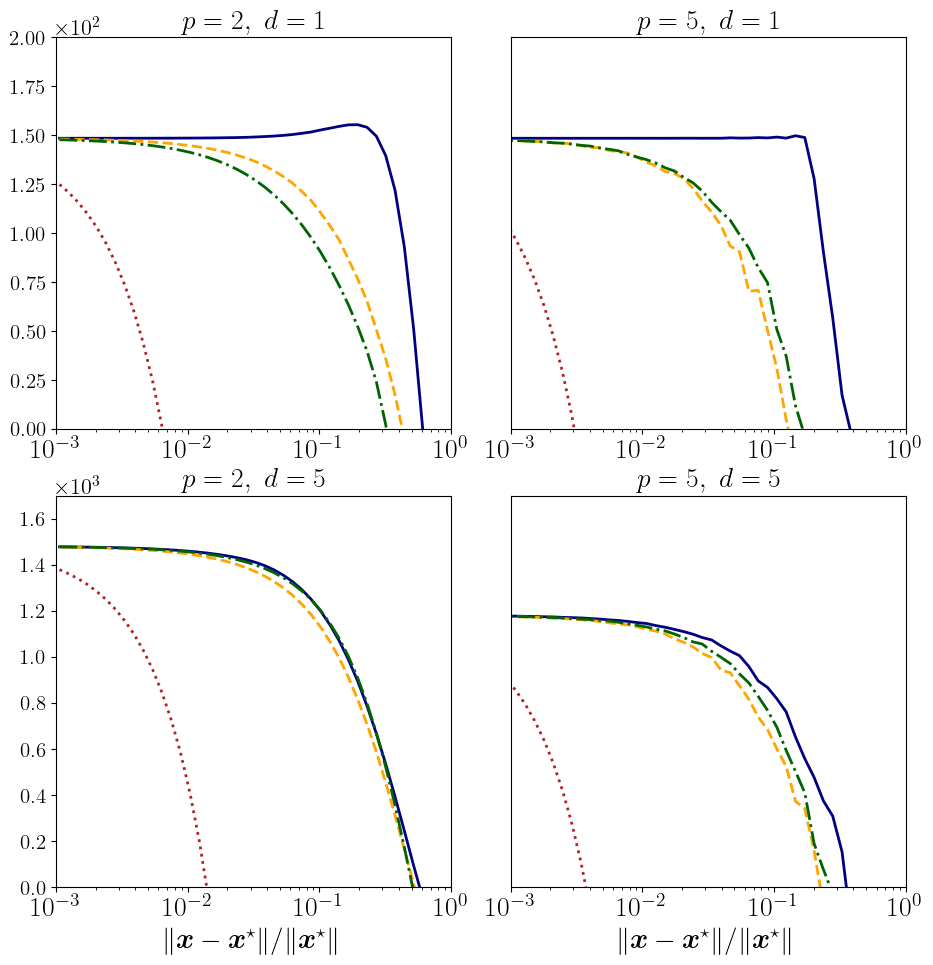

In [4]:

PyPlot.rc("text", usetex=true)
PyPlot.rc("font", family="serif")
PyPlot.rc("text.latex", preamble = raw"\usepackage{amsmath,amssymb,bm}")

data = readdlm("results/noisy_basins_vp_db=Inf.csv", ',', skipstart=1)

pcol = Int.(data[:,1])
dcol = Int.(data[:,2])
xcol = Float64.(data[:,4])

# columns per your CSV writer:
# 11 mineig_mean, 13 lower_r_mean, 15 lower_proj_mean
mineig = Float64.(data[:,11])
lower_vp = Float64.(data[:,13])
lower_r = Float64.(data[:,15])
lower_proj = Float64.(data[:,17])

pd_list = sort(collect(unique(zip(pcol, dcol))))  # should be 4

basins0 = Dict{Tuple{Int,Int}, NamedTuple}()
for (pi, di) in pd_list
    idx = findall((pcol .== pi) .& (dcol .== di))
    ord = sortperm(xcol[idx])
    ii  = idx[ord]
    basins0[(pi,di)] = (
        x = xcol[ii],
        mineig = mineig[ii],
        lower_vp = lower_vp[ii],
        lower_r = lower_r[ii],
        lower_proj = lower_proj[ii],
    )
end

max_y = maximum(maximum(basins0[(p,d)].mineig) for (p,d) in pd_list)
ymax  = 1.2max_y

fig, axs = subplots(2, 2, figsize=(10,10), constrained_layout=false)
axs = vec(axs)

for (idx, (p,d)) in enumerate(pd_list)
    B = basins0[(p,d)]
    ax = axs[idx]

    ax.set_xscale("log")
    if d == 1
        ax.set_ylim(0.0, 200.0)
    else
        ax.set_ylim(0.0, 1700.0)
    end
    ax.set_xlim(1e-3, 1.5e-1)
    ax.set_xticks([1e-3, 1e-2, 1e-1, 1e0])

    ax.set_title(L"p=%$p,\ d=%$d", fontsize=20)

    ax.plot(B.x, B.mineig;     color="navy"     , linestyle="-",  linewidth=2)
    ax.plot(B.x, B.lower_vp;   color="orange"   , linestyle="--",  linewidth=2)
    ax.plot(B.x, B.lower_r;    color="darkgreen", linestyle="-.", linewidth=2)
    ax.plot(B.x, B.lower_proj; color="firebrick", linestyle=":",  linewidth=2)

    if d == 5
        ax.set_xlabel(L"\|\bm{x}-\bm{x}^\star\|/\|\bm{x}^\star\|", fontsize=20)
    end

    if p == 5
        ax.set_yticks([])
    end

    ax.tick_params(axis="x", labelsize=20)
    ax.tick_params(axis="y", labelsize=15)

    # Proper scientific notation
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
    ax.yaxis.get_offset_text().set_fontsize(16)
end

# for (lab, ax) in zip(["(a)", "(c)", "(b)", "(d)"], axs)
#     ax.text(0.02, 0.96, lab; transform=ax.transAxes,
#         va="top", ha="left", fontsize=16,
#         bbox=Dict("facecolor"=>"white","alpha"=>0.7,"edgecolor"=>"none"))
# end

fig.subplots_adjust(left=0.13, right=0.98, bottom=0.10, top=0.95, wspace=0.15, hspace=0.17)
savefig("figures/tsp_var_pro_envelopes.pdf", bbox_inches="tight")
display(fig)


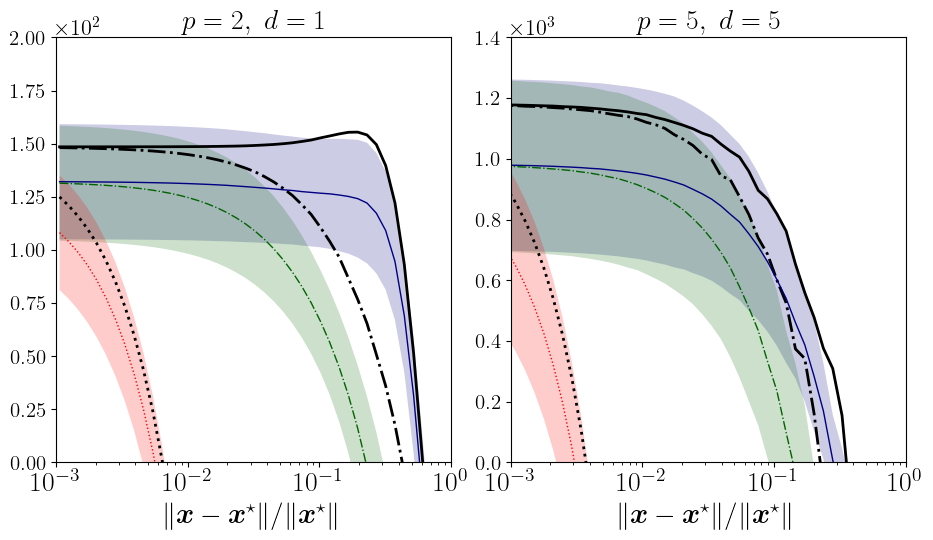

In [5]:
using PyPlot
using LaTeXStrings
using DelimitedFiles

PyPlot.rc("text", usetex=true)
PyPlot.rc("font", family="serif")
PyPlot.rc("text.latex", preamble = raw"\usepackage{amsmath,amssymb,bm}")

# --- helper to plot mean + ribbon in signed_log domain ---
function plot_mean_ribbon!(ax, x, m, s; color, ls, lw, label="")
    y  = m
    yl = m .- s
    yu = m .+ s
    ax.plot(x, y; color=color, linestyle=ls, linewidth=lw, label=label)
    ax.fill_between(x, yl, yu; color=color, alpha=0.20, linewidth=0)
end

# ----------------- load NOISELESS (db=Inf) -----------------
data0 = readdlm("results/noisy_basins_vp_db=Inf.csv", ',', skipstart=1)

p0 = Int.(data0[:,1]); d0 = Int.(data0[:,2]); x0 = Float64.(data0[:,4])
mineig0     = Float64.(data0[:,11])
lower_r0    = Float64.(data0[:,13])
lower_proj0 = Float64.(data0[:,17])

base = Dict{Tuple{Int,Int}, NamedTuple}()
for (pi, di) in unique(zip(p0, d0))
    idx = findall((p0 .== pi) .& (d0 .== di))
    isempty(idx) && continue
    ord = sortperm(x0[idx])
    ii  = idx[ord]
    base[(pi,di)] = (x=x0[ii], mineig=mineig0[ii], lower_r=lower_r0[ii], lower_proj=lower_proj0[ii])
end

# ----------------- load NOISY (e.g. db=0.0) -----------------
data = readdlm("results/noisy_basins_vp_db=0.0.csv", ',', skipstart=1)

p = Int.(data[:,1]); d = Int.(data[:,2]); x = Float64.(data[:,4])
mineig_m = Float64.(data[:,11]); mineig_s = Float64.(data[:,12])
lower_r_m = Float64.(data[:,13]); lower_r_s = Float64.(data[:,14])
lower_proj_m = Float64.(data[:,15]); lower_proj_s = Float64.(data[:,16])

noisy = Dict{Tuple{Int,Int}, NamedTuple}()
for (pi, di) in unique(zip(p, d))
    idx = findall((p .== pi) .& (d .== di))
    isempty(idx) && continue
    ord = sortperm(x[idx])
    ii  = idx[ord]
    noisy[(pi,di)] = (
        x=x[ii],
        mineig_m=mineig_m[ii], mineig_s=mineig_s[ii],
        lower_r_m=lower_r_m[ii], lower_r_s=lower_r_s[ii],
        lower_proj_m=lower_proj_m[ii], lower_proj_s=lower_proj_s[ii],
    )
end

# ----------------- common pd_list (ONLY pairs present in BOTH) -----------------
pd_list = sort!(collect(intersect(Set(keys(base)), Set(keys(noisy)))))

@assert !isempty(pd_list) "No common (p,d) pairs between the two CSVs."

# y-limits: compute safely from only non-empty vectors
vals = Float64[]
for (pi,di) in pd_list
    append!(vals, base[(pi,di)].mineig)
    append!(vals, noisy[(pi,di)].mineig_m)
end

# ----------------- layout: 2x2 if 4 else 1xk -----------------
if length(pd_list) == 4
    fig, axs = subplots(2, 2, figsize=(10,10), constrained_layout=false)
    axs = vec(axs)
else
    fig, axs = subplots(1, length(pd_list), figsize=(10,5), constrained_layout=false)
    axs = length(pd_list) == 1 ? [axs] : vec(axs)
end

for (idx, (p,di)) in enumerate(pd_list)
    ax = axs[idx]
    B0 = base[(p,di)]
    Bn = noisy[(p,di)]

    ax.set_xscale("log")
    if di == 1
        ax.set_ylim(0.0, 200.0)
    else
        ax.set_ylim(0.0, 1400.0)
    end
    ax.set_xlim(1e-3, 1.5e-1)
    ax.set_xticks([1e-3, 1e-2, 1e-1, 1e0])

    ax.set_title(L"p=%$p,\ d=%$di", fontsize=20)

    # noiseless baselines (black)
    ax.plot(B0.x, B0.mineig;     color="black", linestyle="-",  linewidth=2)
    ax.plot(B0.x, B0.lower_r;    color="black", linestyle="-.", linewidth=2)
    ax.plot(B0.x, B0.lower_proj; color="black", linestyle=":",  linewidth=2)

    # noisy (ribbons)
    plot_mean_ribbon!(ax, Bn.x, Bn.mineig_m,     Bn.mineig_s;     color="navy"    , ls="-", lw=1)
    plot_mean_ribbon!(ax, Bn.x, Bn.lower_r_m,    Bn.lower_r_s;    color="darkgreen",  ls="-.", lw=1)
    plot_mean_ribbon!(ax, Bn.x, Bn.lower_proj_m, Bn.lower_proj_s; color="red",  ls=":",  lw=1)

    ax.set_xlabel(L"\|\bm{x}-\bm{x}^\star\|/\|\bm{x}^\star\|", fontsize=20)

    ax.tick_params(axis="x", labelsize=20)
    ax.tick_params(axis="y", labelsize=15)

    # Proper scientific notation
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
    ax.yaxis.get_offset_text().set_fontsize(16)
end

# for (lab, ax) in zip(["(a)", "(b)"], axs)
#     ax.text(0.02, 0.96, lab; transform=ax.transAxes,
#         va="top", ha="left", fontsize=16,
#         bbox=Dict("facecolor"=>"white","alpha"=>0.7,"edgecolor"=>"none"))
# end

fig.subplots_adjust(left=0.13, right=0.98, bottom=0.10, top=0.95, wspace=0.15, hspace=0.25)
savefig("figures/tsp_var_pro_envelopes_noisy.pdf", bbox_inches="tight")
display(fig)
